## Iris Using K - Means & Hierarchical Clustering

### Project Objective

The main objective of this project is to analyze the Iris dataset using clustering techniques, identify natural groups among the Iris flowers based on their features, and apply and compare KMeans and Hierarchical Clustering methods to understand the patterns within the dataset.

### Dataset Features

The Iris dataset contains four numerical features: Sepal Length, Sepal Width, Petal Length, and Petal Width. These features represent the measurements of different parts of the Iris flower and are used to identify similarities and form clusters.

### Import Libraries

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

### 1. Loading & Preprocessing

In [45]:
iris = load_iris()

# Create DataFrame using the feature data
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Dataset Information

In [46]:
df.tail

<bound method NDFrame.tail of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]>

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [48]:
df.shape

(150, 4)

In [49]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Data Cleaning

In [50]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(1)

In [52]:
df = df.drop_duplicates()

In [53]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

### Correlation

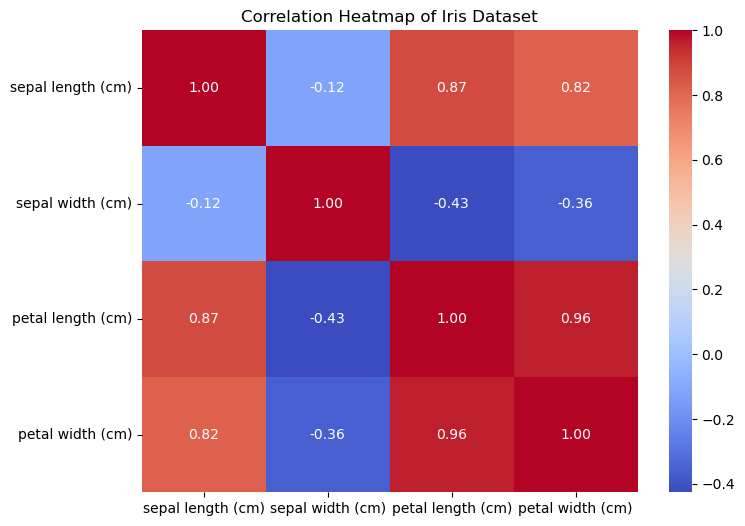

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Iris Dataset")
plt.show()

### Insight:
* Petal Length and Petal Width show a strong positive correlation.
* Sepal Length has a positive correlation with the petal measurements.
* Sepal Width has a relatively lower correlation with the other features.

### Feature Distribution

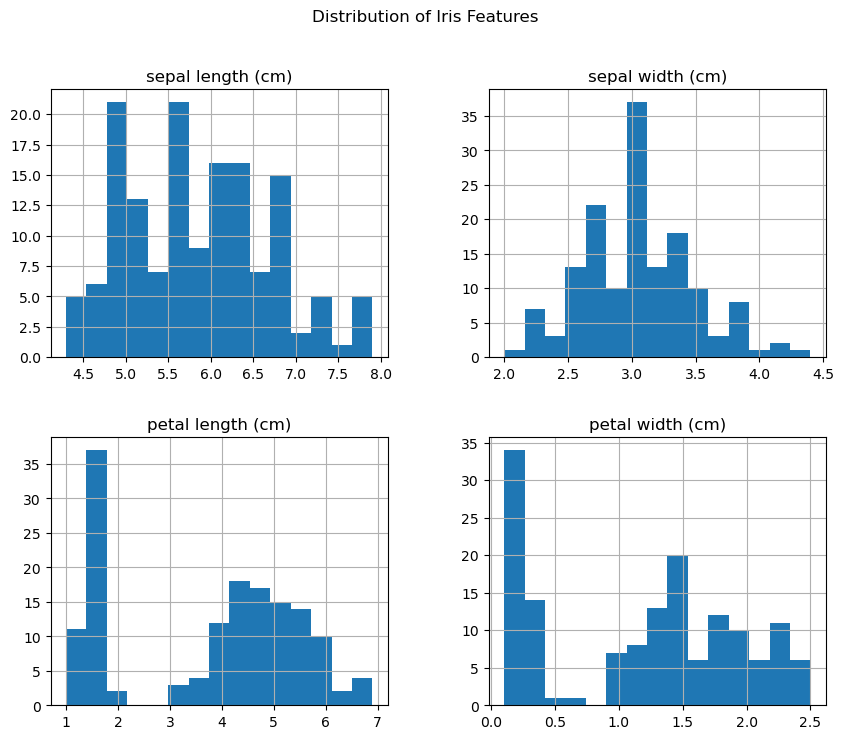

In [55]:
df.hist(figsize=(10, 8), bins=15)

plt.suptitle("Distribution of Iris Features")
plt.show()

### Insight:
* Shows the distribution and variation of the four Iris features.
* Petal features show noticeable differences in their distributions.
* These variations can help identify natural groups.

### Scatter Plot - Sepal

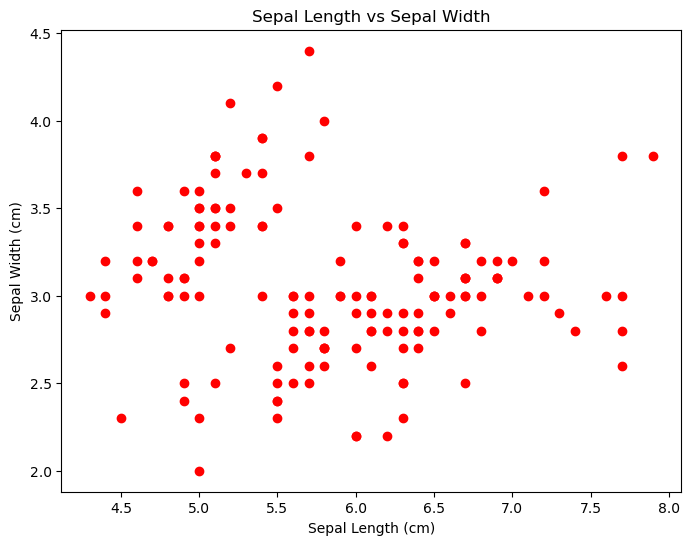

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["sepal length (cm)"],
    df["sepal width (cm)"],
    color="Red"
)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")

plt.show()

### Insight:
* Shows the relationship between Sepal Length and Sepal Width.
* Data points have some overlap.
* Clear cluster separation is not visible.

### Scatter Plot - petal

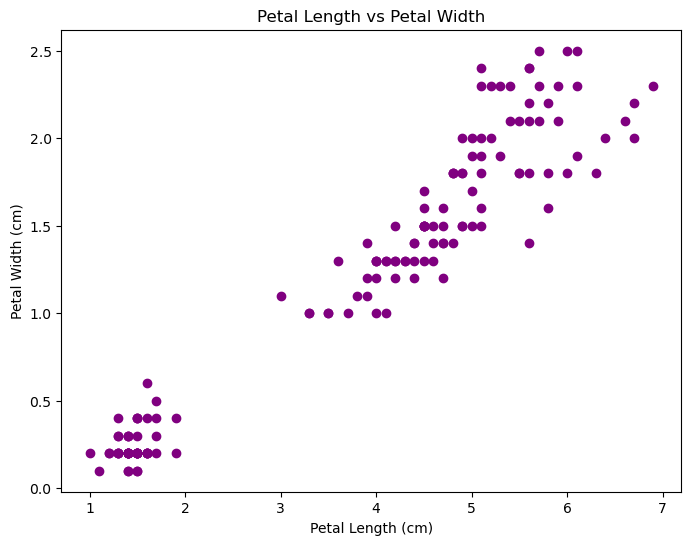

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    color="purple"
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")

plt.show()

### Insight:
* Shows the relationship between Petal Length and Petal Width.
* Data points form more distinct groups.
* Petal features are more useful for clustering.

### Select Features

In [58]:
X = df.select_dtypes(include=['int64', 'float64'])

### Feature Scaling

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [60]:
X_scaled[:5]

array([[-0.8980334 ,  1.01240113, -1.33325507, -1.30862368],
       [-1.13956224, -0.1373532 , -1.33325507, -1.30862368],
       [-1.38109108,  0.32254853, -1.39001364, -1.30862368],
       [-1.5018555 ,  0.09259766, -1.2764965 , -1.30862368],
       [-1.01879782,  1.242352  , -1.33325507, -1.30862368]])

### 2.Clustering Algorithm Implementation

## A) K-Means Clustering


### How KMean Clustering Works ?

KMeans is an unsupervised machine learning algorithm that groups similar data points into a predefined number of clusters (K). It starts by selecting K cluster centroids and assigns each data point to the nearest centroid. The centroids are then updated based on the mean of the assigned data points. This process is repeated until the clusters become stable.

### Why KMean is suitable for the Iris Dataset ?

KMeans clustering is suitable for the Iris dataset because it contains numerical features such as sepal length, sepal width, petal length, and petal width. These features can be used to measure the similarity between data points. The Iris dataset naturally contains three groups, making KMeans with three clusters suitable for identifying these patterns without using the species labels.


In [61]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

### Elbow Method

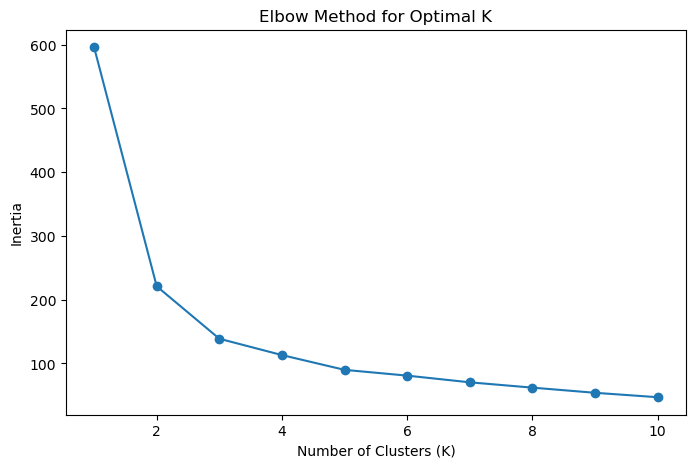

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

### Insight:
* The inertia decreases as the number of clusters increases.
* A clear elbow point is observed at K = 3.
* Therefore, 3 clusters are considered optimal for KMeans clustering.
* This indicates that the Iris dataset can be effectively grouped into three clusters.

#### Apply K-Means

In [63]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_labels

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

#### Visualize K-Means Clusters

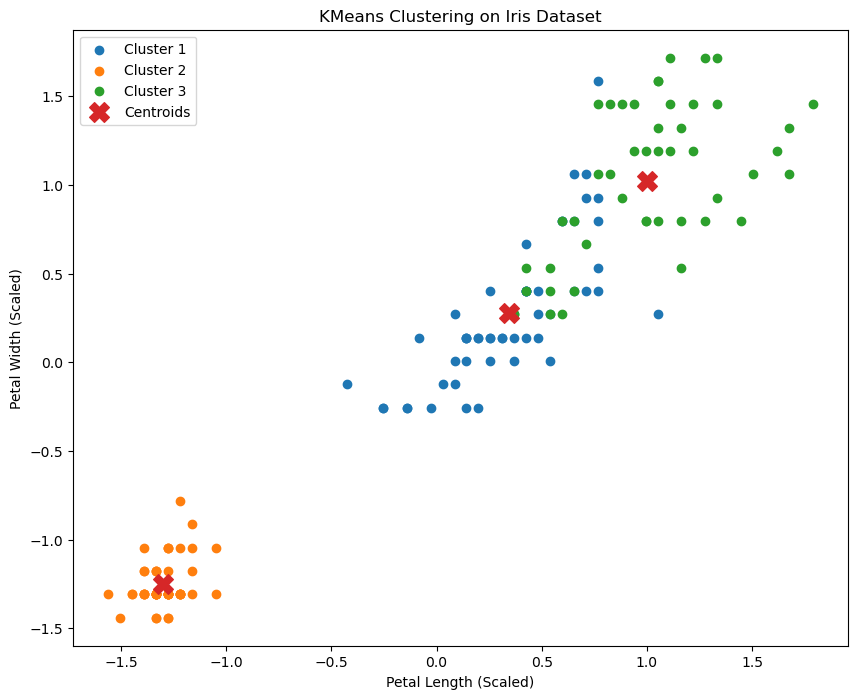

In [65]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X_scaled[kmeans_labels == 0, 2],
    X_scaled[kmeans_labels == 0, 3],
    label="Cluster 1"
)

plt.scatter(
    X_scaled[kmeans_labels == 1, 2],
    X_scaled[kmeans_labels == 1, 3],
    label="Cluster 2"
)

plt.scatter(
    X_scaled[kmeans_labels == 2, 2],
    X_scaled[kmeans_labels == 2, 3],
    label="Cluster 3"
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 2],
    kmeans.cluster_centers_[:, 3],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("KMeans Clustering on Iris Dataset")
plt.legend()
plt.show()

### Insight:

* K-Means successfully grouped the Iris data into 3 clusters based on Petal Length and Petal Width.
* The clusters are clearly separated, showing that these petal features are useful for identifying similar flowers.
* The centroids (X marks) represent the center of each cluster and help assign data points to the nearest cluster.

## B) Hierarchical Clustering

### How dose Hierarchical Clustering work ?

Hierarchical Clustering is an unsupervised machine learning algorithm that groups data points based on their similarity. It starts by considering each data point as a separate cluster. Then, the closest clusters are gradually merged together to form larger clusters. This process continues until the required number of clusters is obtained. The clustering process can be represented using a dendrogram.

### Why is Hierarchical Clustering suitable for the Iris dataset ?

Hierarchical Clustering is suitable for the Iris dataset because it contains numerical features such as sepal length, sepal width, petal length, and petal width. These features can be used to measure the similarity between data points. Hierarchical Clustering can identify groups of similar Iris samples and also helps to understand the relationships between different data points through a dendrogram.

#### Create Dendrogram

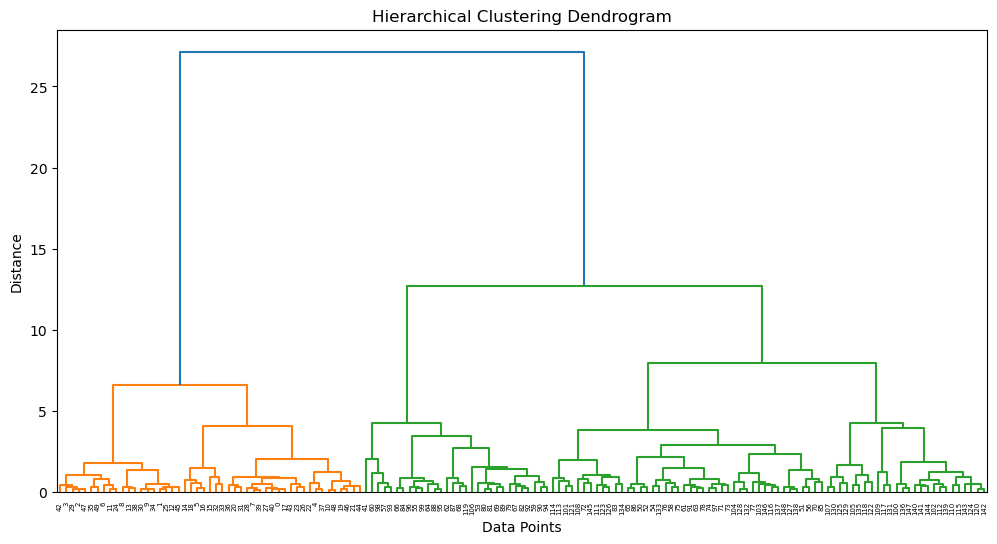

In [24]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

#### Insights:

* The dendrogram shows how similar Iris data points are merged into clusters based on their distance.
* Ward linkage method helps form compact clusters with minimum variation within each cluster.
* The dendrogram indicates that the Iris dataset can be divided into three main clusters.

#### Apply Hierarchical Clustering

In [25]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### Visualize Hierarchical Clusters

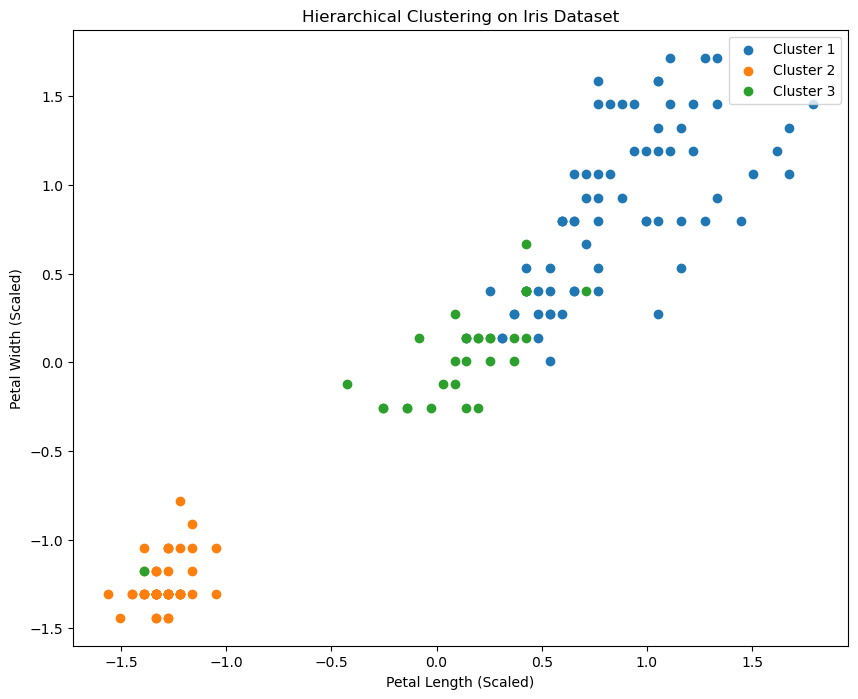

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for i in range(3):
    plt.scatter(
        X_scaled[hierarchical_labels == i, 2],
        X_scaled[hierarchical_labels == i, 3],
        label=f"Cluster {i+1}"
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Hierarchical Clustering on Iris Dataset")
plt.legend()
plt.show()

### Insight:

* The dataset is divided into three clusters.The Petal Length and Petal Width visualization shows a clear separation between the clusters.
* Flowers with smaller petal measurements are mainly grouped into one cluster, while flowers with larger petal measurements are grouped into other clusters.
* A few data points are close to the cluster boundaries, indicating some similarity between groups.
* Overall, Hierarchical Clustering effectively identified meaningful patterns and natural groups in the Iris dataset.


### Clustering Comparison

In [86]:
comparison_counts = pd.DataFrame({
    "K-Means": pd.Series(kmeans_labels).value_counts().sort_index(),
    "Hierarchical": pd.Series(hierarchical_labels).value_counts().sort_index()
})

comparison_counts.index = ["Cluster 1", "Cluster 2", "Cluster 3"]

print(comparison_counts)

           K-Means  Hierarchical
Cluster 1       52            70
Cluster 2       50            49
Cluster 3       47            30


### Conclusion

The Iris dataset was successfully analyzed using unsupervised machine learning techniques. The dataset was preprocessed and standardized before applying the clustering algorithms. K-Means and Hierarchical Clustering were used to group similar Iris flowers based on their sepal and petal measurements. K-Means formed clusters using centroids, while Hierarchical Clustering formed clusters based on the distance between data points and was visualized using a dendrogram. The clustering results showed that both algorithms were able to identify meaningful groups within the Iris dataset. Overall, this project demonstrates how clustering techniques can be used to discover hidden patterns and groups in data without using predefined class labels.